In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
from torch.utils.tensorboard import SummaryWriter
import torchmetrics
import matplotlib.pyplot as plt
from my_dataset import SoilDataset

In [2]:
import multiprocessing
multiprocessing.set_start_method("spawn", force=True)

In [3]:
# get validation set
ds = SoilDataset("../dataset/luca_dataset/lucas_dataset_val.csv")
# get first item
inp, out = ds.__getitem__(0)
# print shapes
print(inp.shape)
print(out.shape)

torch.Size([4200])
torch.Size([12])


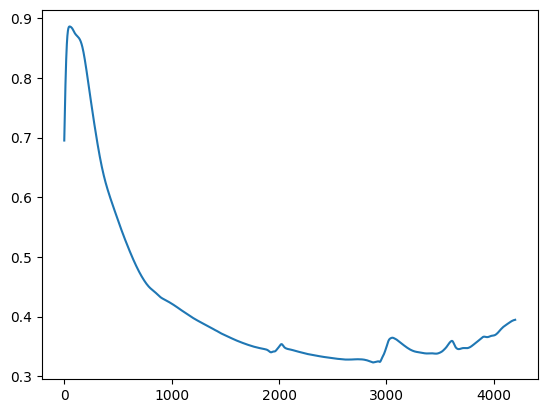

In [4]:
# plot it
plt.plot(inp)
plt.show()

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [6]:
class SoilCNN(nn.Module):
    def __init__(self, out):
        super().__init__()
         # convolutional layers
        self.layer1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=2, padding=3)
        self.layer2 = nn.ReLU()
        self.layer3 = nn.BatchNorm1d(32)

        self.layer4 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.layer5 = nn.ReLU()
        self.layer6 = nn.BatchNorm1d(64)

        self.layer7 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.layer8 = nn.ReLU()
        self.layer9 = nn.BatchNorm1d(128)

        # reduce signal length to 1 automatically
        self.pool = nn.AdaptiveAvgPool1d(1)

        # final linear layer
        self.layer10 = nn.Linear(128, out)
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)

        x = self.layer7(x)
        x = self.layer8(x)
        x = self.layer9(x)

        x = self.pool(x)              # shape: [batch, 128, 1]
        x = x.squeeze(-1)             # shape: [batch, 128]
        x = self.layer10(x)           # shape: [batch, out]

        return x

In [7]:
# create cnn
cnn = SoilCNN(out=12)

# create fake input
inp = torch.rand(10, 1, 20)

# compute output
out = cnn(inp)

print("Output shape:", out.shape)

Output shape: torch.Size([10, 12])


Trian The Model

In [10]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# load only train dataset
train_dataset = SoilDataset("../dataset/luca_dataset/lucas_dataset_train.csv")
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=8, 
    persistent_workers = True)

# model
model = SoilCNN(out=12).to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        if x.dim() == 2:
            x = x.unsqueeze(1)

        x = x.to(device)
        y = y.to(device)

        # If y is one-hot encoded: [batch_size, 12] -> [batch_size]
        if y.dim() > 1:
            y = torch.argmax(y, dim=1)

        y = y.long()

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Using device: mps
Epoch [1/20], Loss: 1.2307
Epoch [2/20], Loss: 0.9663
Epoch [3/20], Loss: 0.9595
Epoch [4/20], Loss: 0.9591
Epoch [5/20], Loss: 0.9537
Epoch [6/20], Loss: 0.9519
Epoch [7/20], Loss: 0.9462
Epoch [8/20], Loss: 0.9465
Epoch [9/20], Loss: 0.9426
Epoch [10/20], Loss: 0.9388
Epoch [11/20], Loss: 0.9356
Epoch [12/20], Loss: 0.9324
Epoch [13/20], Loss: 0.9281
Epoch [14/20], Loss: 0.9244
Epoch [15/20], Loss: 0.9239
Epoch [16/20], Loss: 0.9174
Epoch [17/20], Loss: 0.9143
Epoch [18/20], Loss: 0.9085
Epoch [19/20], Loss: 0.9043
Epoch [20/20], Loss: 0.9006


In [71]:
print(next(model.parameters()).device)

mps:0
